In [135]:
import numpy as np
import matplotlib.pyplot as plt



def signal_sim(T2, f_res, sampling_rate, duration, noise_amplitude, weight_index=0):
    T2 = T2
    f_res = f_res
    sampling_rate = sampling_rate
    duration = duration
    noise_amplitude = noise_amplitude

    time = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)

    signal = np.exp(-time / T2) * np.cos(2 * np.pi * f_res * time)

    noise = np.random.normal(0, noise_amplitude, size=len(time))
    noisy_signal = signal + noise

    fft_signal = np.fft.fft(noisy_signal)
    frequencies = np.fft.fftfreq(len(time), d=1/sampling_rate)

    power_spectrum = np.abs(fft_signal)**2

    # weight = np.exp(-1/((duration-time)/duration))**weight_index
    weight = np.exp(-time/(duration))**weight_index
    weighted_signal = noisy_signal * weight
    fft_signal = np.fft.fft(weighted_signal)
    frequencies = np.fft.fftfreq(len(time), d=1/sampling_rate)

    power_spectrum = np.abs(fft_signal)**2

    peak_index = np.argmax(power_spectrum)
    half_max = power_spectrum[peak_index] / 2

    left_idx = np.where(power_spectrum[:peak_index] < half_max)[0][-1]
    right_idx = peak_index + np.where(power_spectrum[peak_index:] < half_max)[0][0]

    signal_power = np.sum(power_spectrum[left_idx:right_idx])
    noise_power = np.sum(power_spectrum) - signal_power

    snr = 10 * np.log10(signal_power / noise_power)
    return snr, weighted_signal, fft_signal, signal



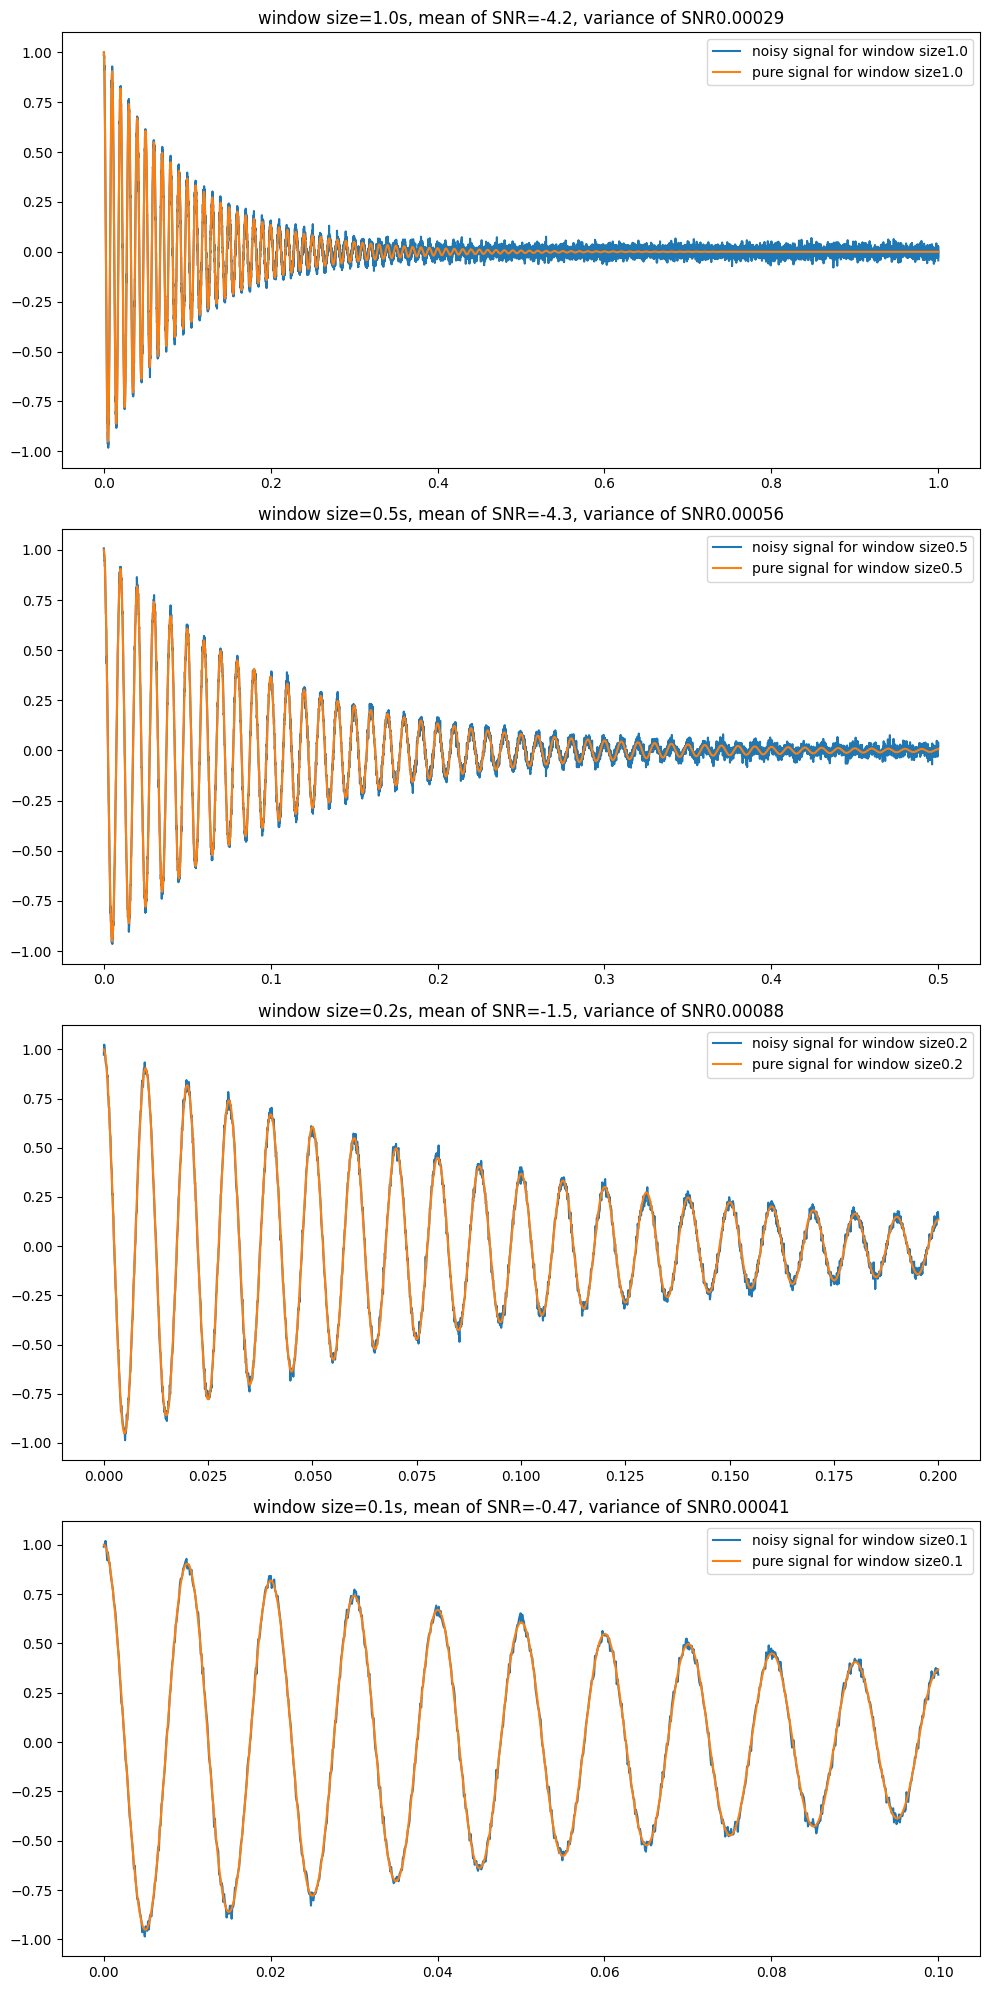

In [110]:
window_list = [1.0, 0.5, 0.2, 0.1]
# window_list = np.linspace(0.01, 1.0, 100)
snr_stats = np.zeros([len(window_list), 2])
fig, axs = plt.subplots(len(window_list), 1, figsize=(10,20))
a = 0
for a, window in enumerate(window_list):
    snr_list = np.zeros(10)
    for i in range(10):
        snr_list[i], noisy_signal, fft_signal, signal = signal_sim(0.1, 100, 10000, window, 0.02, 0)
    snr_norm = np.mean(snr_list)
    snr_var = np.var(snr_list)
    snr_stats[a, 0] = snr_norm
    snr_stats[a, 1] = snr_var
    axs[a].plot(np.linspace(0, window, int(10000*window)), noisy_signal, label=f"noisy signal for window size{window:.2}")
    axs[a].plot(np.linspace(0, window, int(10000*window)), signal, label=f"pure signal for window size{window:.2}")
    axs[a].legend()
    axs[a].set_title(f"window size={window:.2}s, mean of SNR={snr_norm:.2}, variance of SNR{snr_var:.2}")
plt.tight_layout()
plt.show()
    

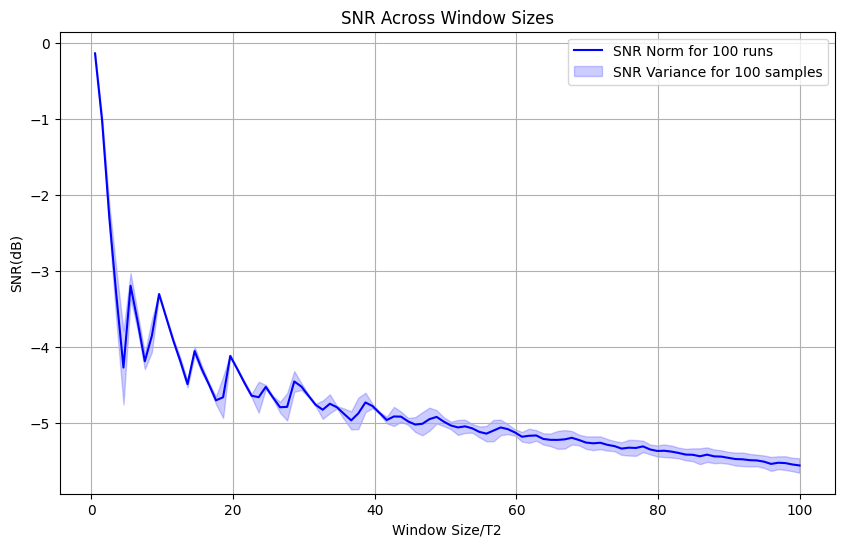

In [111]:
window_list = np.linspace(0.05, 10.0, 100)
snr_stats = np.zeros([len(window_list), 2])
a = 0
samples = 100
for a, window in enumerate(window_list):
    snr_list = np.zeros(samples)
    for i in range(samples):
        snr_list[i], noisy_signal, fft_signal, signal = signal_sim(0.1, 100, 10000, window, 0.02, 0)
    snr_norm = np.mean(snr_list)
    snr_var = np.var(snr_list)
    snr_stats[a, 0] = snr_norm
    snr_stats[a, 1] = snr_var

plt.figure(figsize=(10, 6))
plt.plot(window_list/0.1, snr_stats[:,0], label='SNR Norm for 100 runs', color='blue')
plt.fill_between(window_list/0.1, snr_stats[:,0] - np.sqrt(snr_stats[:,1]), snr_stats[:,0] + np.sqrt(snr_stats[:,1]), 
                 color='blue', alpha=0.2, label='SNR Variance for 100 samples')

plt.title("SNR Across Window Sizes")
plt.xlabel("Window Size/T2")
plt.ylabel("SNR(dB)")
plt.legend()
plt.grid(True)
plt.show()

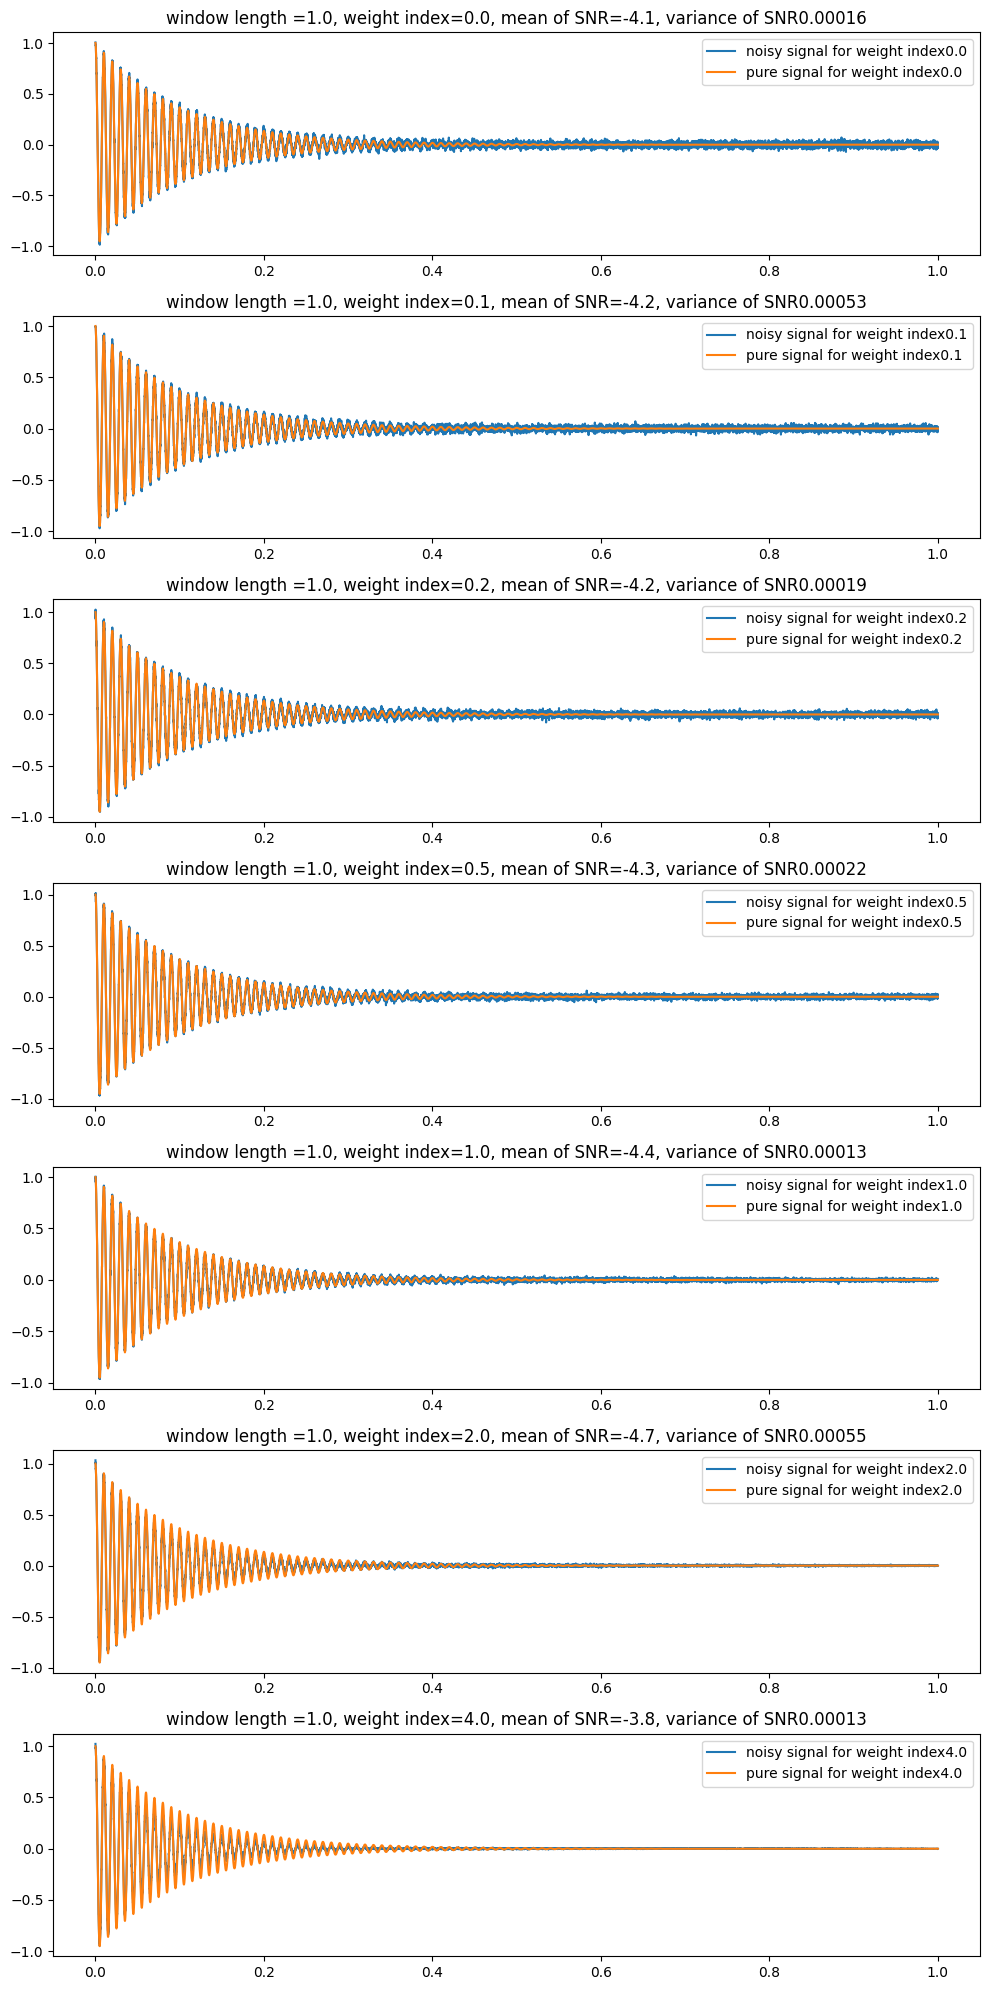

In [138]:
index_list = [0.0, 0.1, 0.2, 0.5, 1.0, 2.0, 4.0]
snr_stats = np.zeros([len(index_list), 2])
fig, axs = plt.subplots(len(index_list), 1, figsize=(10,20))
a = 0
wd = 1.0
for a, index in enumerate(index_list):
    snr_list = np.zeros(10)
    for i in range(10):
        snr_list[i], noisy_signal, fft_signal, signal = signal_sim(0.1, 100, 10000, wd, 0.02, index)
    snr_norm = np.mean(snr_list)
    snr_var = np.var(snr_list)
    snr_stats[a, 0] = snr_norm
    snr_stats[a, 1] = snr_var
    axs[a].plot(np.linspace(0, wd, int(10000*wd)), noisy_signal, label=f"noisy signal for weight index{index:.2}")
    axs[a].plot(np.linspace(0, wd, int(10000*wd)), signal, label=f"pure signal for weight index{index:.2}")
    axs[a].legend()
    axs[a].set_title(f"window length ={wd:.2}, weight index={index:.2}, mean of SNR={snr_norm:.2}, variance of SNR{snr_var:.2}")
plt.tight_layout()
plt.show()
    